In [1]:
import os
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

This dataset is synthetically generated to mimic weather data for classification tasks. It includes various weather-related features and categorizes the weather into four types: Rainy, Sunny, Cloudy, and Snowy. This dataset is designed for practicing classification algorithms, data preprocessing, and outlier detection methods.
download form: 
https://www.kaggle.com/datasets/nikhil7280/weather-type-classification?resource=download

### Read the dataset and extract labels and features

In [2]:
df = pd.read_csv('weather_classification_data.csv')

In [3]:
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy


Data Summary:
- The dataset contains 13200 rows and 11 columns.
- Categorical Attribute: Cloud Cover, Season, Location, Weather Type
- Continuous Attributes: Temperature, Humidity,	Wind Speed, Precipitation (%), Atmospheric Pressure, UV Index, Visibility (km)

We will use only continuous attributes to predict the label.

In [4]:
weather_mapping = {'Rainy': 1, 'Cloudy': 2, 'Sunny': 3, 'Snowy': 4}
df['Label'] = df['Weather Type'].map(weather_mapping)
df_re = df.drop(columns=['Weather Type', 'Cloud Cover', 'Season', 'Location'])

In [5]:
df_re

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Label
0,14.0,73,9.5,82.0,1010.82,2,3.5,1
1,39.0,96,8.5,71.0,1011.43,7,10.0,2
2,30.0,64,7.0,16.0,1018.72,5,5.5,3
3,38.0,83,1.5,82.0,1026.25,7,1.0,3
4,27.0,74,17.0,66.0,990.67,1,2.5,1
...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,1003.15,1,1.0,1
13196,-1.0,76,3.5,23.0,1067.23,1,6.0,4
13197,30.0,77,5.5,28.0,1012.69,3,9.0,2
13198,3.0,76,10.0,94.0,984.27,0,2.0,4


### 1. Display the statistical values for each of the attributes, along with visualizations (e.g., histogram) of the distributions for each attribute. Are there any attributes that might require special treatment? If so, what special treatment might they require? [2 points]

**Statistical descriptions and Visualizations**

In [6]:
df_re.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Label
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917,2.500000
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499,1.118076
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000,1.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000,1.750000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000,2.500000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000,3.250000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000,4.000000


In [7]:
df_features_only = df_re.drop(columns=['Label'])

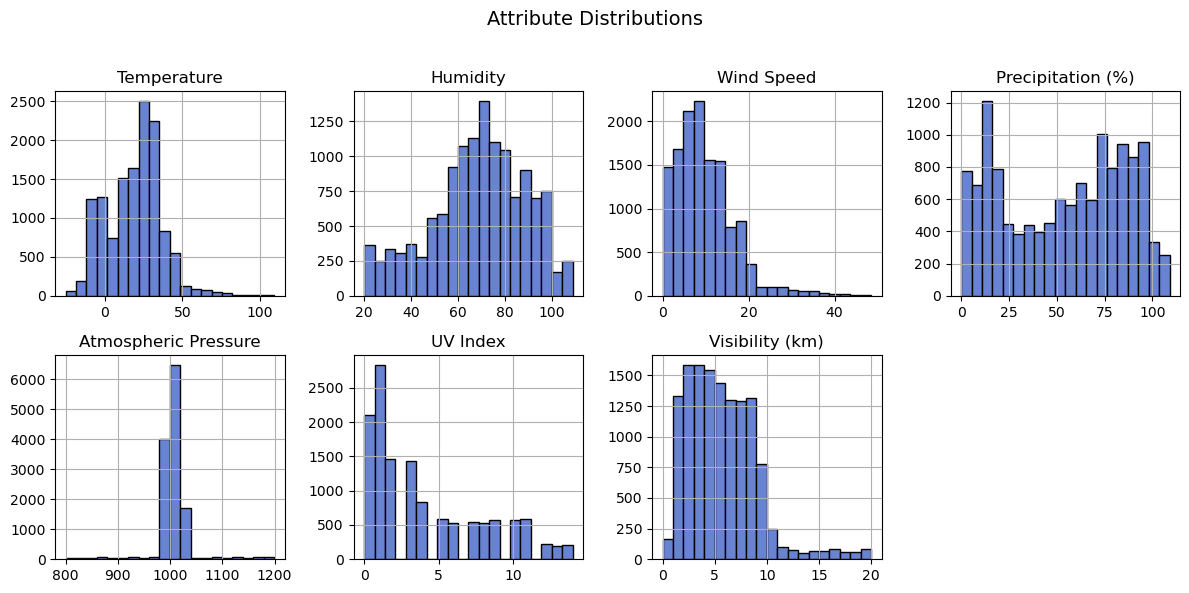

In [8]:
# Create subplots with 3 rows and 4 columns
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Attribute Distributions", fontsize=14)

# Flatten the axes array for easy iteration
ax = ax.flatten()

# Plot histograms for each attribute
for i, column in enumerate(df_features_only.columns):
    df_features_only[column].hist(ax=ax[i], bins=20, color='#6883d2', edgecolor='black')
    ax[i].set_title(column)
    ax[i].grid(True)



ax[-1].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

**Here are potential attributes that might require special treatment:**

- Wind Speed and UV Index: Both attributes are heavily skewed toward lower values, meaning they have long right tails.
  Log transformation or power transformation (e.g., Box-Cox) might help normalize the data if required for statistical modeling.
  
- Atmospheric Pressure: The histogram suggests a highly concentrated distribution around 1000 hPa, with very few extreme values.
  If extreme values are due to data errors or rare weather events, filtering or capping outliers might be necessary.

  
- Visibility (km): The distribution appears skewed, with a concentration of values at lower visibility levels.
  Similar to wind speed, a transformation might be useful, or thresholding could help categorize low vs. high visibility events.

### 2. Analyze and discuss the relationships between the data attributes and between the data attributes and labels. This involves computing the Pearson Correlation Coefficient (PCC) and generating scatter plots. [3 points]

**Computing the PCC**

In [9]:
df_re

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Label
0,14.0,73,9.5,82.0,1010.82,2,3.5,1
1,39.0,96,8.5,71.0,1011.43,7,10.0,2
2,30.0,64,7.0,16.0,1018.72,5,5.5,3
3,38.0,83,1.5,82.0,1026.25,7,1.0,3
4,27.0,74,17.0,66.0,990.67,1,2.5,1
...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,1003.15,1,1.0,1
13196,-1.0,76,3.5,23.0,1067.23,1,6.0,4
13197,30.0,77,5.5,28.0,1012.69,3,9.0,2
13198,3.0,76,10.0,94.0,984.27,0,2.0,4


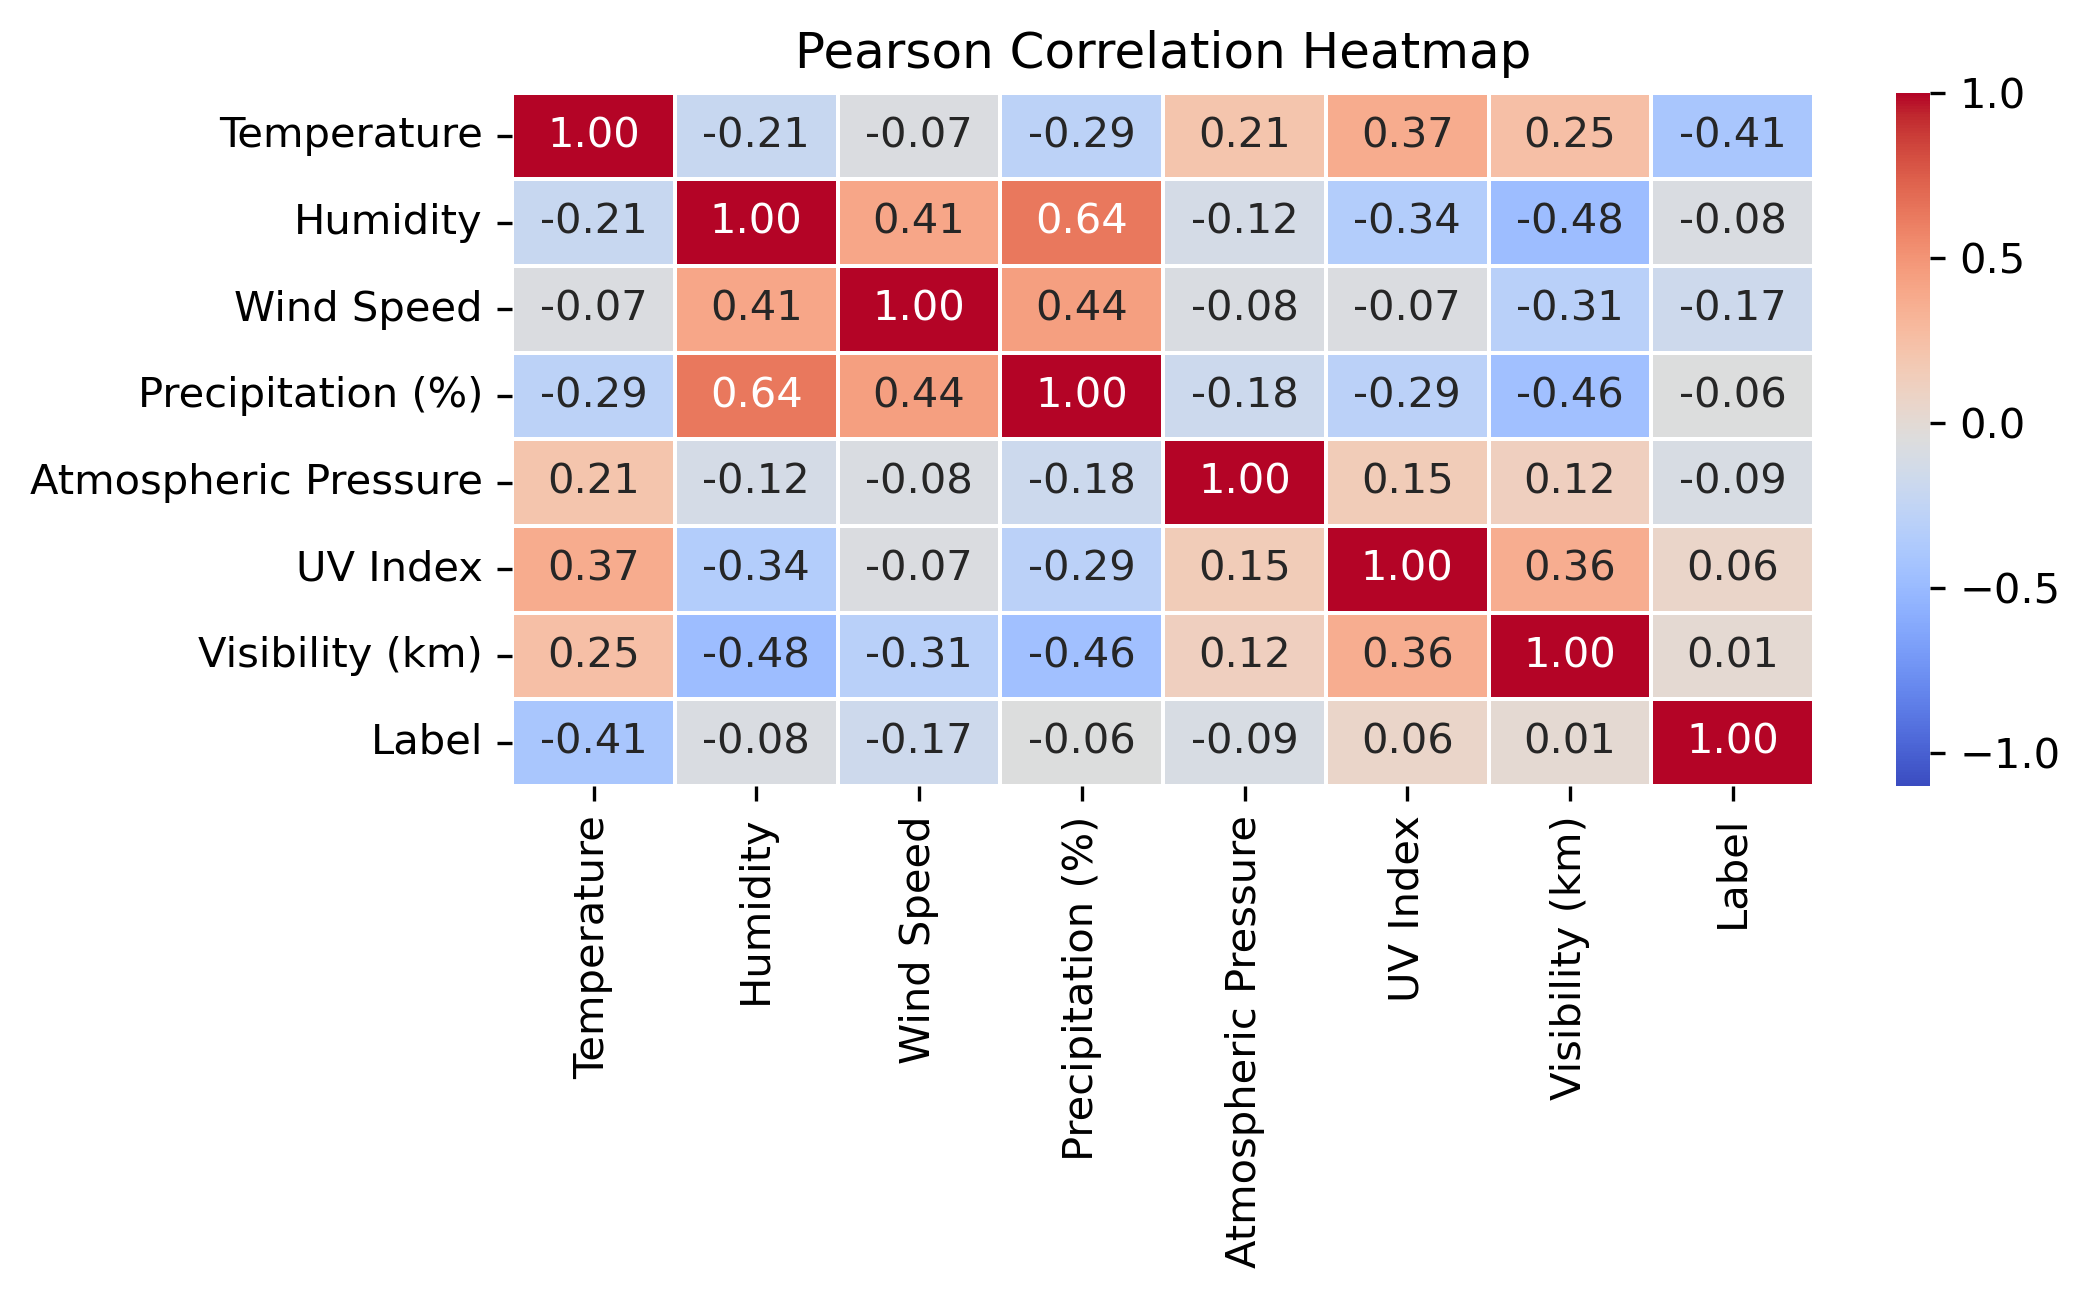

In [10]:
# Compute Pearson Correlation Coefficient (PCC)
correlation_matrix = df_re.corr()

# Plot Pearson Correlation Heatmap
fig, axes = plt.subplots(1, 1, figsize=(7, 3), dpi=300)  # Single figure for heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=axes, vmin=1, vmax=-1)
axes.set_title("Pearson Correlation Heatmap")
plt.show()

**Scatter Plots**

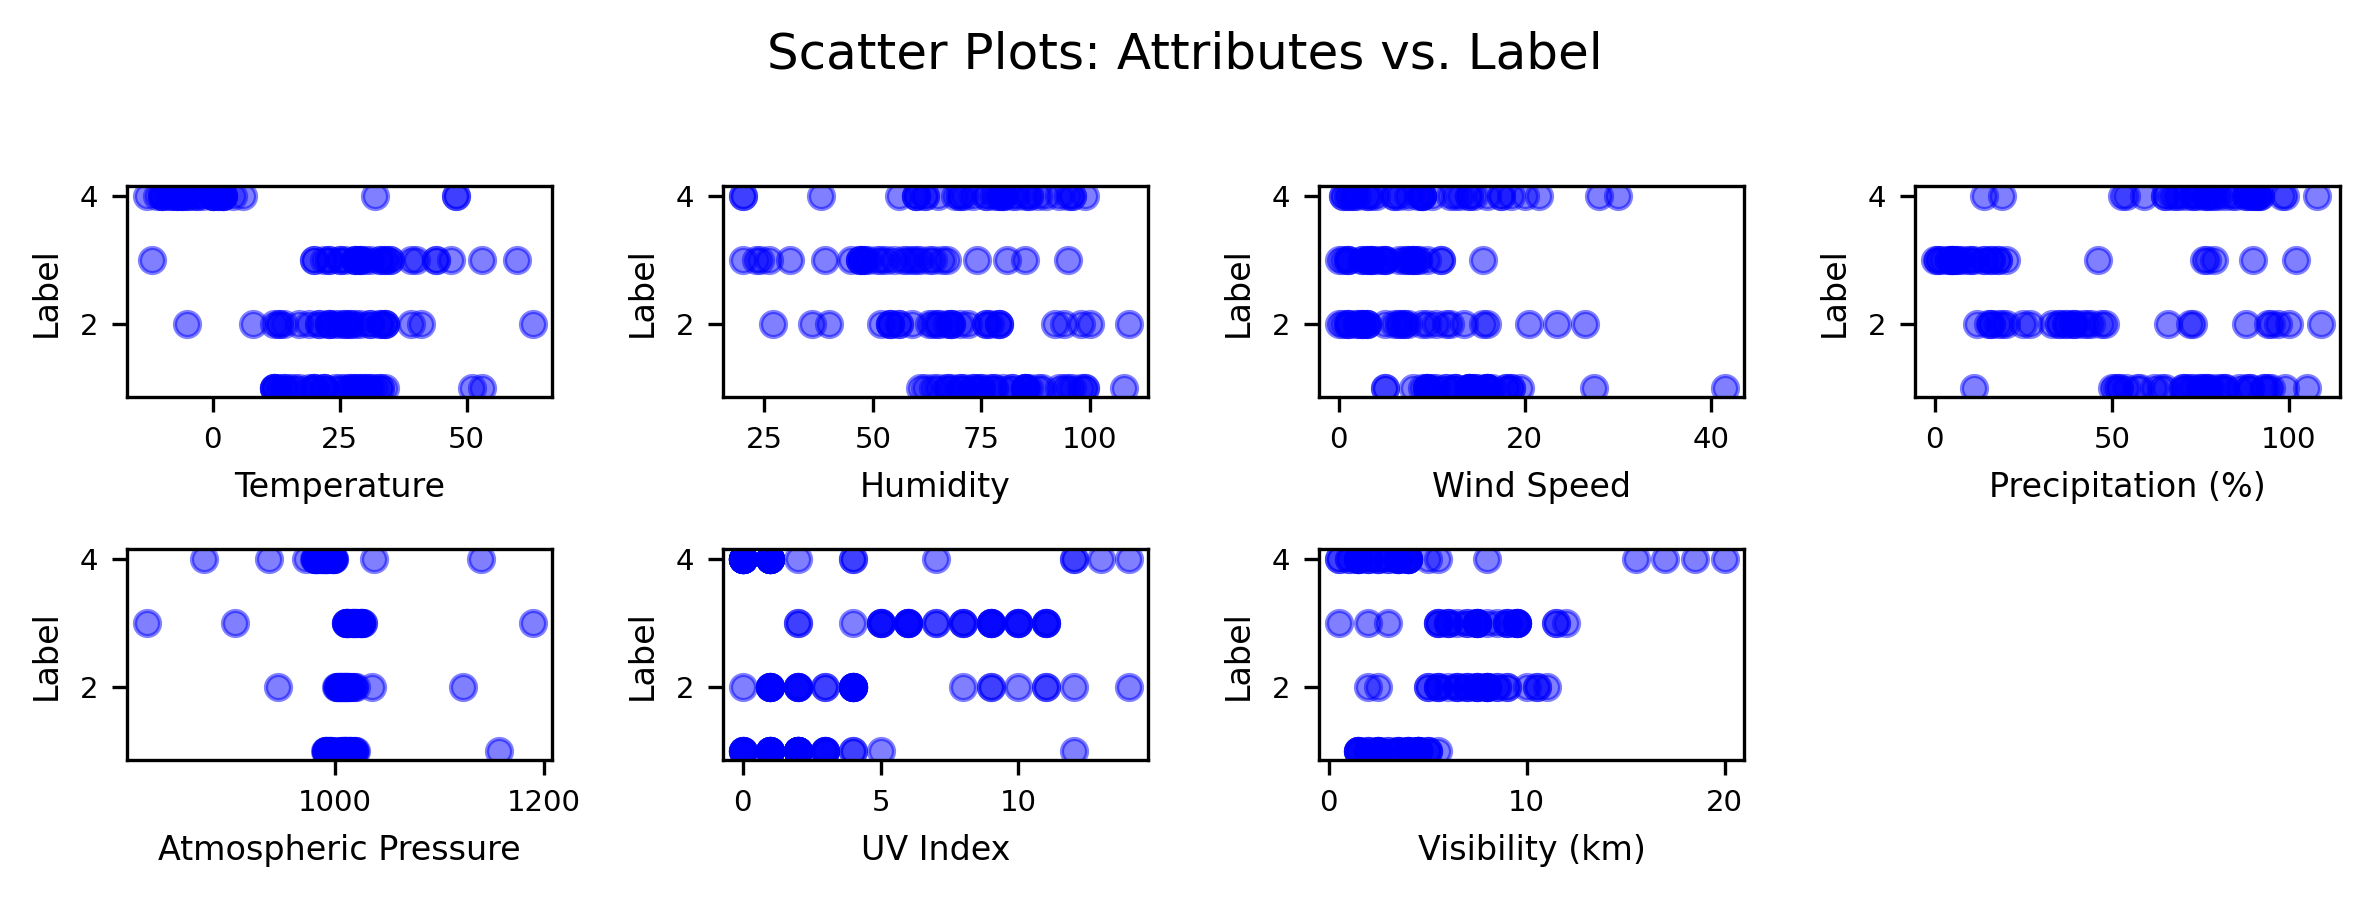

In [11]:
features = df_re.columns[:7]  

fig, axes = plt.subplots(2, 4, figsize=(8, 3), dpi=300)
fig.suptitle("Scatter Plots: Attributes vs. Label", fontsize=12)

axes = axes.flatten()

for i, feature in enumerate(features):
    # Because the dataset is large, plot one data point every 100 points.
    axes[i].scatter(df_re[feature][::100], df_re["Label"][::100], alpha=0.5, color="blue")
    axes[i].set_xlabel(feature, fontsize=8)
    axes[i].set_ylabel("Label", fontsize=8)

    axes[i].tick_params(axis='both', labelsize=7)
    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()


### 3. For training data, use token numbers 1-10, for validation 11 to 13, and for testing 14 to 16 (each of the 30 rock subtypes has 16 token numbers). [5 points]

**Splitting the data in testing , validation and training sets correctly**

In [12]:
df_re

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Label
0,14.0,73,9.5,82.0,1010.82,2,3.5,1
1,39.0,96,8.5,71.0,1011.43,7,10.0,2
2,30.0,64,7.0,16.0,1018.72,5,5.5,3
3,38.0,83,1.5,82.0,1026.25,7,1.0,3
4,27.0,74,17.0,66.0,990.67,1,2.5,1
...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,1003.15,1,1.0,1
13196,-1.0,76,3.5,23.0,1067.23,1,6.0,4
13197,30.0,77,5.5,28.0,1012.69,3,9.0,2
13198,3.0,76,10.0,94.0,984.27,0,2.0,4


In [13]:
from sklearn.model_selection import train_test_split

# First, split off 60% for training and 40% for a temporary set (validation + testing)
train, temp = train_test_split(df_re, test_size=0.4, random_state=42)

# Then, split the temporary set equally into validation and test sets (20% each of the total data)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print("Training set shape:", train.shape)
print("Validation set shape:", val.shape)
print("Testing set shape:", test.shape)


Training set shape: (7920, 8)
Validation set shape: (2640, 8)
Testing set shape: (2640, 8)


**Verification of splitting**

Compare summary statistics

In [14]:
train.describe() 

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Label
count,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000
mean,19.363131,68.590278,9.833270,53.502904,1005.895847,4.023359,5.464331,2.488258
std,17.286645,20.159064,6.929279,31.915744,36.266142,3.866582,3.337655,1.114196
min,-24.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000,1.000000
25%,5.000000,57.000000,5.000000,19.000000,995.210000,1.000000,3.000000,1.000000
50%,22.000000,70.000000,8.500000,58.000000,1007.655000,3.000000,5.000000,2.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.700000,7.000000,7.500000,3.000000
max,109.000000,109.000000,47.500000,109.000000,1198.970000,14.000000,20.000000,4.000000


In [15]:
val.describe() 

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Label
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,18.651894,68.675379,9.777273,53.189015,1005.866489,3.972348,5.509470,2.528788
std,17.557172,20.215707,6.814839,32.030198,39.873677,3.836808,3.432302,1.115160
min,-24.000000,20.000000,0.000000,0.000000,801.250000,0.000000,0.000000,1.000000
25%,3.000000,57.000000,5.000000,20.000000,994.147500,1.000000,3.000000,2.000000
50%,21.000000,70.000000,9.000000,57.000000,1007.770000,3.000000,5.000000,3.000000
75%,30.000000,83.000000,13.500000,82.000000,1016.960000,7.000000,7.500000,4.000000
max,108.000000,109.000000,48.500000,109.000000,1194.980000,14.000000,20.000000,4.000000


In [16]:
test.describe() 

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Label
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,18.896591,69.107955,9.883902,54.524242,1005.585451,3.986364,5.412121,2.506439
std,17.506246,20.280715,6.942223,31.950941,37.208389,3.847486,3.411531,1.132370
min,-25.000000,20.000000,0.000000,0.000000,802.470000,0.000000,0.000000,1.000000
25%,3.000000,57.750000,5.000000,20.000000,994.067500,1.000000,3.000000,1.000000
50%,21.000000,70.000000,9.000000,60.000000,1007.565000,3.000000,5.000000,3.000000
75%,30.000000,84.000000,13.500000,83.000000,1016.752500,7.000000,7.500000,4.000000
max,98.000000,109.000000,45.000000,109.000000,1199.210000,14.000000,20.000000,4.000000


Histogram & Kernel Density Estimation: If the two curves overlap well, the test set is likely representative.

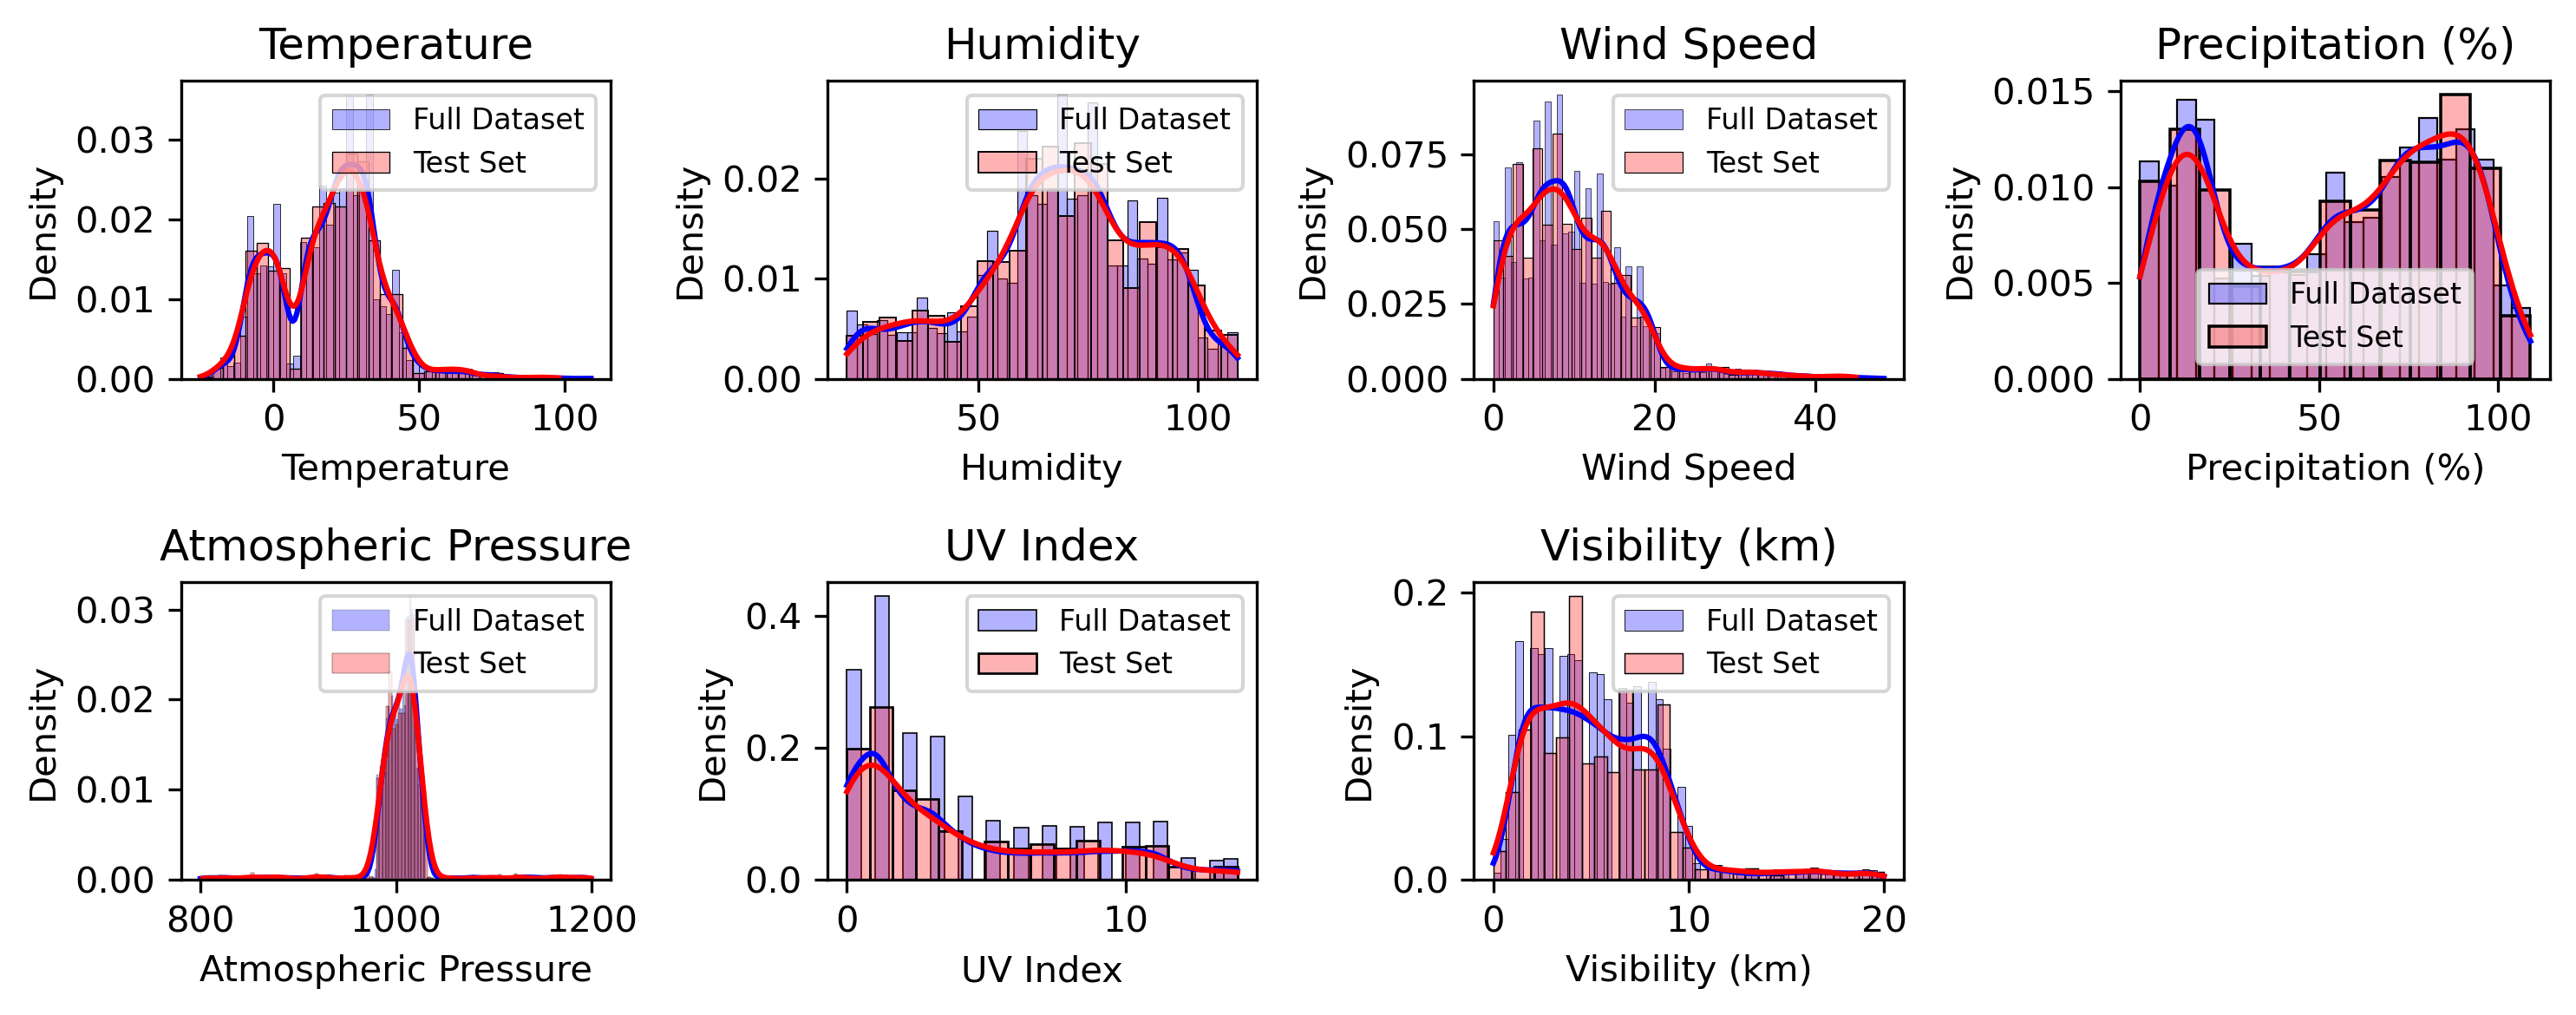

In [17]:
# Create the full dataset by dropping the "token number" column
full_data = df_re

features = df_re.columns[0:7]

fig, axes = plt.subplots(2, 4, figsize=(10, 4), dpi=300)
axes = axes.flatten()  

for ax, feature in zip(axes, features):
    sns.histplot(full_data[feature], kde=True, stat="density",
                 label="Full Dataset", color="blue", alpha=0.3, ax=ax)
    sns.histplot(test[feature], kde=True, stat="density",
                 label="Test Set", color="red", alpha=0.3, ax=ax)
    ax.set_title(feature)
    ax.legend(fontsize=8)

for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


In [18]:
import scipy.stats as stats

# Extract features (excluding 'label' and 'token number')
features = df_re.columns[0:7]

# Perform the KS test for each feature
for feature in features:

    full_feature_data = full_data[feature].dropna()
    test_feature_data = test[feature].dropna()
    
    # Apply the Kolmogorov-Smirnov test
    ks_statistic, p_value = stats.ks_2samp(full_feature_data, test_feature_data)
    
    # Print out the test results for the feature
    print(f"Feature: {feature}", f"  KS Statistic: {ks_statistic:.4f}", f"  p-value: {p_value:.4f}\n")


Feature: Temperature   KS Statistic: 0.0128   p-value: 0.8589

Feature: Humidity   KS Statistic: 0.0146   p-value: 0.7289

Feature: Wind Speed   KS Statistic: 0.0081   p-value: 0.9985

Feature: Precipitation (%)   KS Statistic: 0.0196   p-value: 0.3606

Feature: Atmospheric Pressure   KS Statistic: 0.0185   p-value: 0.4347

Feature: UV Index   KS Statistic: 0.0058   p-value: 1.0000

Feature: Visibility (km)   KS Statistic: 0.0178   p-value: 0.4829



### 4. Train different classifiers and tweak the hyperparameters to improve performance (you can use the grid search if you want or manually try different values). Report training, validation and testing performance (classification accuracy, precision, recall and F1 score) and discuss the impact of the hyperparameters (use markdown cells in Jupyter Notebook to clearly indicate each solution):
- A. Multinomial Logistic Regression (Softmax Regression); hyperparameters to explore: C, solver, max number of iterations. [10 points]
- B. Support Vector Machine (make sure to try using kernels); hyperparameters to explore: C, kernel, degree of polynomial kernel, gamma.  [10 points]
- C. Random Forest classifier (also analyze feature importance); hyperparameters to explore: the number of trees, max depth, the minimum number of samples required to split an internal node, the minimum number of samples required to be at a leaf node. [10 points]

**A. Multinomial Logistic Regression (Softmax Regression); hyperparameters to explore: C, solver, max number of iterations. [10 points]**

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


Model implementation and Hyperparameter Tuning

In [20]:
X_train = train.drop(columns=['Label'])
y_train = train['Label']

X_val = val.drop(columns=['Label'])
y_val = val['Label']

X_test = test.drop(columns=['Label'])
y_test = test['Label']

# Define the hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
    'max_iter': [100, 500, 1000]
}

best_val_accuracy = 0.0
best_params = None
best_model = None

# Loop through each combination of hyperparameters
for C in param_grid['C']:
    for solver in param_grid['solver']:
        for max_iter in param_grid['max_iter']:
            try:
                # Create the logistic regression model with the current hyperparameters
                model = LogisticRegression(
                    multi_class='multinomial',
                    penalty='l2',
                    C=C,
                    solver=solver,
                    max_iter=max_iter
                )
                # Fit the model on the training data
                model.fit(X_train, y_train)
                
                # Predict on the validation set and compute validation accuracy
                y_val_pred = model.predict(X_val)
                val_acc = accuracy_score(y_val, y_val_pred)
                
                # If current model performs better than previous ones, update best parameters and model
                if val_acc > best_val_accuracy:
                    best_val_accuracy = val_acc
                    best_params = {'C': C, 'solver': solver, 'max_iter': max_iter}
                    best_model = model
                    
            except Exception as e:
                print(f"Error with parameters C={C}, solver={solver}, max_iter={max_iter}: {e}")
                continue

print("\nBest hyperparameters based on validation accuracy:")
print(best_params)
print("Best validation accuracy: {:.4f}".format(best_val_accuracy))


Best hyperparameters based on validation accuracy:
{'C': 0.1, 'solver': 'newton-cg', 'max_iter': 100}
Best validation accuracy: 0.8701


Discussion on the impact of different hyper parameters

C (Inverse Regularization Strength):

- The best result was obtained with C = 0.1, which indicates that applying relatively strong regularization helped improve generalization on the validation set. A lower value of C penalizes large coefficients more, leading to a smoother decision boundary and potentially reducing overfitting. In our case, setting C too high might have allowed the model to overfit the training data, while C = 0.1 struck a good balance between bias and variance.

Solver:

- The chosen solver, 'newton-cg', outperformed other options such as 'lbfgs', 'sag', and 'saga' on the dataset. The 'newton-cg' method uses second-order derivative information, which can be advantageous for convergence when the data dimensionality is moderate. It seems that for this dataset, 'newton-cg' provided a more efficient optimization path, leading to better performance on the validation set.

max_iter (Maximum Number of Iterations):
- The best result was reported at max_iter = 100. This suggests that the solver converged quickly, and allowing more iterations did not improve performance—in fact, it might have unnecessarily increased computational cost or even led to overfitting if the model started over-optimizing on the training data. Using a lower max_iter value here ensured that the algorithm stopped as soon as it found an optimal or near-optimal solution.

Overall, the best hyperparameter combination { 'C': 0.1, 'solver': 'newton-cg', 'max_iter': 100 } indicates that strong regularization with a well-suited solver and a moderate number of iterations was most effective for this dataset. This combination helped the model achieve a high validation accuracy of 87.01%, reflecting a good balance between model complexity and generalization ability.

Training, Validation and Testing Performance

In [21]:
# the best model on the training set using best_params
best_model = LogisticRegression(
    multi_class='multinomial',
    penalty='l2',
    C=best_params['C'],
    solver=best_params['solver'],
    max_iter=best_params['max_iter']
)
best_model.fit(X_train, y_train)

# Evaluate on the Training set
y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print("Training Performance:")
print("  Accuracy: {:.4f}".format(train_accuracy))
print("  Precision: {:.4f}".format(train_precision))
print("  Recall: {:.4f}".format(train_recall))
print("  F1 Score: {:.4f}".format(train_f1))

# Evaluate on the Validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print("\nValidation Performance:")
print("  Accuracy: {:.4f}".format(val_accuracy))
print("  Precision: {:.4f}".format(val_precision))
print("  Recall: {:.4f}".format(val_recall))
print("  F1 Score: {:.4f}".format(val_f1))

# Evaluate on the Testing set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTesting Performance:")
print("  Accuracy: {:.4f}".format(test_accuracy))
print("  Precision: {:.4f}".format(test_precision))
print("  Recall: {:.4f}".format(test_recall))
print("  F1 Score: {:.4f}".format(test_f1))

print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))


Training Performance:
  Accuracy: 0.8667
  Precision: 0.8668
  Recall: 0.8667
  F1 Score: 0.8665

Validation Performance:
  Accuracy: 0.8701
  Precision: 0.8704
  Recall: 0.8701
  F1 Score: 0.8699

Testing Performance:
  Accuracy: 0.8659
  Precision: 0.8657
  Recall: 0.8659
  F1 Score: 0.8655

Classification Report for Test Set:
              precision    recall  f1-score   support

           1       0.85      0.88      0.86       687
           2       0.82      0.81      0.81       604
           3       0.88      0.83      0.85       674
           4       0.91      0.94      0.92       675

    accuracy                           0.87      2640
   macro avg       0.86      0.86      0.86      2640
weighted avg       0.87      0.87      0.87      2640



**Key Metrics Analysis: Training Set vs. Validation Set**

The validation accuracy is slightly higher than the training accuracy, which suggests that the model is not overfitting to the training set. Generally, if the training accuracy were much higher than the validation accuracy, that would be a sign of overfitting.

Precision, Recall, F1 Score:
- These metrics are also very close between training and validation sets, indicating that the model’s performance is consistent and generalizes well to unseen data (the validation set). There is no significant drop-off from training to validation, reinforcing that the model is well-regularized and not memorizing the training data.

Conclusion:
The model shows comparable performance on training and validation, suggesting good generalization and minimal overfitting.

**Key Metrics Analysis: Validation Set vs. Test Set**

The difference in accuracy is quite small (~0.0042), implying the model’s performance on the test set is nearly the same as on the validation set.

Precision, Recall, F1 Score:
- Again, the metrics remain consistent. If there had been a large gap (e.g., validation F1 much higher than test F1), it would suggest potential overfitting to the validation set during hyperparameter tuning. Here, however, the small difference indicates stable, reliable performance.

Conclusion: The validation and test metrics are closely aligned, indicating that the model’s hyperparameters were chosen well and it generalizes effectively to new, unseen data.

**Comparison of Evaluation Metrics**

- Accuracy (0.87): Gives an overall view of how often the model predicts correctly.
- Precision, Recall, F1 (0.86–0.87): These metrics show the model balances between correctly predicting positive samples (precision) and capturing the majority of actual positive samples (recall). The F1 score (0.87) suggests a good trade-off between precision and recall.
- Class-Level Performance: From the classification report, each class has reasonably high precision and recall, though some classes may have slightly higher precision but lower recall, or vice versa. The macro and weighted averages (0.86–0.87) confirm that performance is fairly balanced across classes.
- Conclusion: All key metrics—accuracy, precision, recall, and F1—are in the mid-to-high 0.80s across training, validation, and test sets. This consistency across multiple splits and metrics strongly indicates that the model is both accurate and well-generalized, without significant overfitting or underfitting.

**B. Support Vector Machine (make sure to try using kernels); hyperparameters to explore: C, kernel, degree of polynomial kernel, gamma. [10 points]**

Model implementation and hyperparameters tuning

In [22]:
# Example param_grid for SVM
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'degree': [2, 3, 4, 5, 6]  # Only used if kernel='poly'
}

# Create an SVM model
svm = SVC()

# --------------------------------------------------------
# 2. Grid Search over the specified hyperparameters
# --------------------------------------------------------
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='accuracy',     # Can also try other metrics like 'f1_weighted'
    cv=5,                   # 5-fold cross-validation
    n_jobs=-1,             # Use all available CPU cores
    verbose=1              # Print progress messages
)

# Fit grid search on the training data
# Here, we run every 100 points; it might be that the high degree value is causing the slow performance
grid_search.fit(X_train[::100], y_train[::100])

# --------------------------------------------------------
# 3. Identify the best hyperparameters
# --------------------------------------------------------
print("Best parameters found:", grid_search.best_params_)

# Retrieve the best model from grid search
best_svm = grid_search.best_estimator_

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best parameters found: {'C': 10, 'degree': 5, 'gamma': 'scale', 'kernel': 'poly'}


After performing a grid search over the hyperparameters ‘C‘,‘kernel‘,‘gamma‘,‘degree‘ on the combined training and validation sets, the best estimator was found to be:

SVC(C: 10, degree: 5, gamma: 'scale', kernel: 'poly')

Training, Validation and Testing Performance have been reported :3

In [23]:
# Evaluate performance on the Training Set (make predictions using best model)
y_train_pred = best_svm.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print("Training Performance:")
print(f"  Accuracy:  {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1 Score:  {train_f1:.4f}")

# Evaluate performance on the Validation Set
y_val_pred = best_svm.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print("\nValidation Performance:")
print(f"  Accuracy:  {val_accuracy:.4f}")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall:    {val_recall:.4f}")
print(f"  F1 Score:  {val_f1:.4f}")

# Evaluate performance on the Test Set
y_test_pred = best_svm.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTesting Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

# Print a detailed classification report for the Test Set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Training Performance:
  Accuracy:  0.8043
  Precision: 0.8217
  Recall:    0.8043
  F1 Score:  0.8039

Validation Performance:
  Accuracy:  0.8140
  Precision: 0.8319
  Recall:    0.8140
  F1 Score:  0.8135

Testing Performance:
  Accuracy:  0.8080
  Precision: 0.8278
  Recall:    0.8080
  F1 Score:  0.8062

Classification Report (Test Set):
              precision    recall  f1-score   support

           1       0.71      0.89      0.79       687
           2       0.78      0.76      0.77       604
           3       0.97      0.64      0.77       674
           4       0.85      0.92      0.89       675

    accuracy                           0.81      2640
   macro avg       0.83      0.81      0.81      2640
weighted avg       0.83      0.81      0.81      2640



**Performance Overview**

**Training vs. Validation vs. Test**

Training Accuracy ~0.80, Validation Accuracy ~0.81, Test Accuracy ~0.81

- The model’s performance is consistent across all three sets, suggesting minimal overfitting.
- The small gap (about 1% difference) indicates that the model generalizes relatively well to unseen data.

Precision, Recall, F1 all hover around the low 0.80s across training, validation, and testing.

- This consistency further confirms that the model is not heavily overfitting or underfitting.

**Class-Level Results (Test Set)**

- Some classes (e.g., Class 3) show high precision (0.97) but relatively lower recall (0.64), meaning the model is very confident when it predicts Class 3 but may miss some instances that truly belong to Class 3.
- Other classes (e.g., Class 1) have moderate precision (0.71) but higher recall (0.89), so the model captures most Class 1 instances but also includes some misclassifications as Class 1.
- The overall weighted average F1 ~0.81 indicates a balanced performance across classes.

**Impact of Hyperparameters**

C (Regularization Parameter)

- A larger C places more emphasis on correctly classifying all training samples, potentially leading to overfitting if the model becomes too complex.
- A smaller C enforces stronger regularization, simplifying the decision boundary at the risk of underfitting.
- Results (Accuracy ~0.80–0.81) suggest that the chosen C strikes a reasonable balance between bias (underfitting) and variance (overfitting).

Kernel Type (linear, poly, rbf, sigmoid)

- Linear Kernel: Suited for linearly separable data; tends to be simpler and faster but may underfit complex patterns.
- Polynomial Kernel (poly): Controlled by the degree parameter; can capture more complex relationships but is more computationally expensive and can overfit if degree is too high.
- RBF Kernel (rbf): Often a strong default choice for many datasets; controlled by gamma. It can capture complex, non-linear boundaries.
Sigmoid Kernel: Sometimes useful but can be trickier to tune.
- Final performance around 0.80–0.81 suggests that the chosen kernel can handle the data’s complexity without overfitting.

Gamma (for rbf, poly, or sigmoid kernels)

- High gamma creates tighter decision boundaries around training samples, which can lead to overfitting if too high.
- Low gamma produces smoother, broader decision boundaries, potentially underfitting if it’s too small.
- If used gamma='scale' or gamma='auto', scikit-learn internally adjusts gamma based on the feature space, often providing a good starting point.

Degree (for poly Kernel)

- The degree parameter controls the complexity of the polynomial function.
- Higher degrees can fit more complex data but at the risk of overfitting and slower training.
- If the best model ended up with a relatively lower or moderate degree, it suggests that a very high polynomial expansion might not have been necessary (or might have overfit).


Overall, my SVM model demonstrates good performance and a reasonable balance among accuracy, precision, recall, and F1 across all splits. Further refinements—such as exploring additional data preprocessing, feature engineering, or class balancing—could potentially improve performance on individual classes.

**C. Random Forest classifier (also analyze feature importance); hyperparameters to explore: the number of trees, max depth, the minimum number of samples required to split an internal node, the minimum number of samples required to be at a leaf node. [10 points]**

In [24]:
# parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

# Create a Random Forest model
rf = RandomForestClassifier(random_state=42)

# --------------------------------------------------------
# Grid Search over the specified hyperparameters
# --------------------------------------------------------
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',   # Can also try 'f1_weighted' or others
    cv=5,                 # 5-fold cross-validation
    n_jobs=-1,            # use all available CPU cores
    verbose=1             # show progress
)

# Fit grid search on the training data
grid_search.fit(X_train[::100], y_train[::100])

# --------------------------------------------------------
# Identify the best hyperparameters and best model
# --------------------------------------------------------
print("Best parameters found:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [25]:
# Evaluate the best model on Training, Validation, and Test sets
# --------------------------------------------------------

# --- Training Set ---
y_train_pred = best_rf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print("\nTraining Performance:")
print(f"  Accuracy:  {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1 Score:  {train_f1:.4f}")

# --- Validation Set ---
y_val_pred = best_rf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print("\nValidation Performance:")
print(f"  Accuracy:  {val_accuracy:.4f}")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall:    {val_recall:.4f}")
print(f"  F1 Score:  {val_f1:.4f}")

# --- Test Set ---
y_test_pred = best_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTesting Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# --------------------------------------------------------
# Analyze Feature Importance
# --------------------------------------------------------
importances = best_rf.feature_importances_

# Assuming X_train is a pandas DataFrame so columns can be used as feature names
feature_importances = pd.Series(importances, index=X_train.columns)
feature_importances.sort_values(ascending=False, inplace=True)

print("\nFeature Importances (Descending Order):")
print(feature_importances)


Training Performance:
  Accuracy:  0.8562
  Precision: 0.8640
  Recall:    0.8562
  F1 Score:  0.8564

Validation Performance:
  Accuracy:  0.8568
  Precision: 0.8664
  Recall:    0.8568
  F1 Score:  0.8570

Testing Performance:
  Accuracy:  0.8568
  Precision: 0.8646
  Recall:    0.8568
  F1 Score:  0.8566

Classification Report (Test Set):
              precision    recall  f1-score   support

           1       0.78      0.93      0.85       687
           2       0.80      0.79      0.80       604
           3       0.93      0.76      0.83       674
           4       0.94      0.93      0.94       675

    accuracy                           0.86      2640
   macro avg       0.86      0.85      0.86      2640
weighted avg       0.86      0.86      0.86      2640


Feature Importances (Descending Order):
Temperature             0.218215
Precipitation (%)       0.218034
Visibility (km)         0.188148
Humidity                0.131304
UV Index                0.099026
Atmospheric Pr

**Performance Overview**

- I achieve consistent accuracy across training (0.8562), validation (0.8568), and test sets (0.8568).
- Class-level metrics show strong recall for some classes and high precision for others, maintaining an overall balanced performance.
- My weighted average F1 score of 0.86 indicates that the model performs robustly on all classes.

**Impact of Hyperparameters**

- n_estimators: Number of trees in the forest.
A higher number of trees (e.g., 200) often stabilizes performance by reducing variance but increases training time.
- max_depth: The maximum depth of each tree.
None allows trees to grow until all leaves are pure or until they contain fewer than  min_samples_split samples. This can capture complex patterns but might risk overfitting if not controlled by other parameters. A shallower max_depth (like 5 or 10) can reduce variance and improve generalization.
- min_samples_split: The minimum number of samples required to split an internal node.
Larger values (e.g., 5) make the trees shallower and reduce overfitting but can slightly underfit if set too high.
- min_samples_leaf: The minimum number of samples required to be at a leaf node.
Similar to min_samples_split, this prevents leaves from having very few samples. Larger values typically produce smoother decision boundaries.
- The final hyperparameter combination (as found by GridSearchCV) balances these parameters in a way that yields ~85.6% accuracy across training, validation, and test sets. This consistency implies the chosen parameters are controlling the complexity well—neither underfitting nor overfitting.

**Feature Importance**

- Temperature and Precipitation have the highest importance, suggesting that the model relies heavily on these two features to distinguish between classes.
- Visibility and Humidity are also influential, indicating that environmental factors significantly contribute to predicting the label.
- Wind Speed shows relatively lower importance but may still provide complementary information.

Feature importance in a Random Forest is determined by how much each feature reduces impurity (or improves predictive power) across all trees. These values can guide further analysis, such as focusing on collecting more precise data for the top features or potentially engineering additional relevant features (e.g., temperature ranges or precipitation patterns).

**Conclusion**

I find that the chosen hyperparameters produce a stable model with minimal overfitting. Temperature, precipitation, and visibility emerge as the most critical features, aligning well with domain expectations. Overall, I am satisfied with the Random Forest’s balance of accuracy, interpretability, and generalization.

### 5. Combine your classifiers into an ensemble and try to outperform each individual classifier on the validation set. Once you have found a good one, try it on the test set. Describe and discuss your findings. [10 points]

In [26]:
from sklearn.ensemble import VotingClassifier

In [27]:
# the best Logistic Regression model
best_lr = LogisticRegression(
    multi_class='multinomial',
    C=best_params['C'],
    solver=best_params['solver'],
    max_iter=best_params['max_iter'],
    random_state=42
)
best_lr.fit(X_train, y_train)

# Create an ensemble using VotingClassifier with hard voting
ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('svm', best_svm),
        ('lr', best_lr)
    ],
    voting='hard'  # 'hard' voting based on majority class votes
)
ensemble.fit(X_train, y_train)

# ------------------------------------------------------------------
# Evaluate individual models on Validation Set
# ------------------------------------------------------------------
models = [('Random Forest', best_rf),
          ('SVM', best_svm),
          ('Logistic Regression', best_lr),
          ('Ensemble', ensemble)]
for name, model in models:
    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted')
    val_recall = recall_score(y_val, y_val_pred, average='weighted')
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    
    print(f"\n{name} - Validation Performance:")
    print(f"  Accuracy:  {val_accuracy:.4f}")
    print(f"  Precision: {val_precision:.4f}")
    print(f"  Recall:    {val_recall:.4f}")
    print(f"  F1 Score:  {val_f1:.4f}")



Random Forest - Validation Performance:
  Accuracy:  0.8568
  Precision: 0.8664
  Recall:    0.8568
  F1 Score:  0.8570

SVM - Validation Performance:
  Accuracy:  0.8140
  Precision: 0.8319
  Recall:    0.8140
  F1 Score:  0.8135

Logistic Regression - Validation Performance:
  Accuracy:  0.8701
  Precision: 0.8704
  Recall:    0.8701
  F1 Score:  0.8699

Ensemble - Validation Performance:
  Accuracy:  0.8792
  Precision: 0.8812
  Recall:    0.8792
  F1 Score:  0.8791


In [28]:

# ------------------------------------------------------------------
# Evaluate the best ensemble on the Test Set
# ------------------------------------------------------------------
print("\nEvaluating Ensemble on the Test Set:")
y_test_pred = ensemble.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Evaluating Ensemble on the Test Set:
  Accuracy:  0.8780
  Precision: 0.8795
  Recall:    0.8780
  F1 Score:  0.8775

Classification Report (Test Set):
              precision    recall  f1-score   support

           1       0.83      0.92      0.87       687
           2       0.87      0.81      0.84       604
           3       0.91      0.83      0.87       674
           4       0.91      0.94      0.93       675

    accuracy                           0.88      2640
   macro avg       0.88      0.88      0.88      2640
weighted avg       0.88      0.88      0.88      2640



**Performance on the Validation Set**  
The ensemble classifier achieved an accuracy of 0.8792 on the validation set, which surpasses the performance of the individual models (Random Forest: 0.8568, SVM: 0.8140, Logistic Regression: 0.8701). This improvement indicates that integrating predictions from diverse classifiers enhances the ability to capture complex data patterns and reduces individual model weaknesses.

**Performance on the Test Set**  
On the test set, the ensemble maintained a strong performance with an accuracy of 0.878. The classification report shows balanced precision and recall across classes, with F1-scores ranging from 0.84 to 0.93. These results confirm that the ensemble generalizes well to unseen data, delivering consistent and robust predictions.

**Discussion**  
The ensemble method effectively combines the strengths of Random Forest, SVM, and Logistic Regression through hard voting, wherein the majority class prediction is selected. This approach mitigates the shortcomings of individual models by leveraging their complementary strengths. Overall, the enhanced performance on both validation and test sets demonstrates that the ensemble approach not only improves accuracy but also increases the stability and robustness of the predictive model.